# MMDetection

## Load libs

In [ ]:
from mmdet.apis import DetInferencer

from pathlib import Path

import pandas as pd

import subprocess

import time

import torch

import textwrap

from ultralytics import YOLO

import warnings


from scripts.check_dataset import check_dataset

from scripts.coco_to_yolo import coco_to_yolo

from scripts.make_report import (
                                 evaluate_detection_map_pr,
                                 fps_from_ultralytics_speed,
                                 fcos_outputs_to_preds ,
                                 yolo_results_to_preds,
                                )

from scripts.process_video import (
                                   make_fcos_infer_fn,
                                   make_yolo_infer_fn,
                                   process_video_generic
                                  )


from scripts.voc_to_coco_json import CLASSES, voc_to_coco

from scripts.visualization import (
                                   draw_distribution, 
                                   draw_pricture,
                                   draw_fcos_metrics,
                                   draw_yolo_metrics,
                                   show_n_images,
                                   visualize_images_with_boxes, 
                                  )

warnings.filterwarnings("ignore", message="torch.meshgrid: in an upcoming release")

## EDA

Paths

In [2]:
project_dir_path: Path = Path(__name__).parent.resolve()
dataset_dir_name: Path = Path("datasets")
dataset_dir_path: Path = project_dir_path / dataset_dir_name
minecraft_dataset_dir_name: Path = "minecraft"
minecraft_dataset_dir_path: Path = dataset_dir_path / minecraft_dataset_dir_name

train_folder_name: Path = Path("images/train")
minecraft_train_dataset_path: Path = minecraft_dataset_dir_path / train_folder_name

valid_folder_name: Path = Path("images/valid")
minecraft_valid_dataset_path: Path = minecraft_dataset_dir_path / valid_folder_name

test_folder_name: Path = Path("images/test")
minecraft_test_dataset_path: Path = minecraft_dataset_dir_path / test_folder_name


print("DATASET DIR PATH:                  ", dataset_dir_path)
print("MINECRAFT DATASET DIR PATH:        ", minecraft_dataset_dir_path)
print()
print("MINECRAFT DATASET TRAIN DIR PATH:  ", minecraft_train_dataset_path)
print("MINECRAFT DATASET VALID DIR PATH:  ", minecraft_valid_dataset_path)
print("MINECRAFT DATASET TEST DIR PATH:   ", minecraft_test_dataset_path)

DATASET DIR PATH:                   /home/ubuntu/mmdetection/mmdet/datasets
MINECRAFT DATASET DIR PATH:         /home/ubuntu/mmdetection/mmdet/datasets/minecraft

MINECRAFT DATASET TRAIN DIR PATH:   /home/ubuntu/mmdetection/mmdet/datasets/minecraft/images/train
MINECRAFT DATASET VALID DIR PATH:   /home/ubuntu/mmdetection/mmdet/datasets/minecraft/images/valid
MINECRAFT DATASET TEST DIR PATH:    /home/ubuntu/mmdetection/mmdet/datasets/minecraft/images/test


Checking datasets

In [3]:
train_files_paths: list[Path]  = check_dataset(minecraft_train_dataset_path)


JPG NUMS: 2305
XML NUMS: 2305

=== DATASET TRAIN IS CORRECT ===

The total number of files that will be used:  4610


2023-04-03_19_17_30_png.rf.8ca8dad6210d53c762b3b8df9bbb5db2.jpg -> missing: xml

In [4]:
valid_files_paths: list[Path]  = check_dataset(minecraft_valid_dataset_path)


JPG NUMS: 422
XML NUMS: 422

=== DATASET VALID IS CORRECT ===

The total number of files that will be used:  844


In [5]:
test_files_paths: list[Path]  = check_dataset(minecraft_test_dataset_path)


JPG NUMS: 155
XML NUMS: 155

=== DATASET TEST IS CORRECT ===

The total number of files that will be used:  310


Convert VOC.xml to COCO.json

In [6]:
voc_to_coco(train_files_paths)

TRAIN DATASET: The conversion has been completed
TRAIN ANNOTAION WAS SAVED: /home/ubuntu/mmdetection/mmdet/datasets/minecraft/annotations/train.json


In [7]:
voc_to_coco(valid_files_paths)

VALID DATASET: The conversion has been completed
VALID ANNOTAION WAS SAVED: /home/ubuntu/mmdetection/mmdet/datasets/minecraft/annotations/valid.json


In [8]:
voc_to_coco(test_files_paths)

TEST DATASET: The conversion has been completed
TEST ANNOTAION WAS SAVED: /home/ubuntu/mmdetection/mmdet/datasets/minecraft/annotations/test.json


Convert COCO.json to YOLO

In [9]:
train_annotation_path: str = str(minecraft_dataset_dir_path / Path("annotations") / Path("train.json"))
valid_annotation_path: str = str(minecraft_dataset_dir_path / Path("annotations") / Path("valid.json"))
test_annotation_path: str = str(minecraft_dataset_dir_path / Path("annotations") / Path("test.json"))

labels_yolo_dir_path: str = str(minecraft_dataset_dir_path / Path("labels"))
labels_yolo_train_dir_path: str = str(minecraft_dataset_dir_path / Path("labels") / Path("train"))
labels_yolo_valid_dir_path: str = str(minecraft_dataset_dir_path / Path("labels") / Path("valid"))
labels_yolo_test_dir_path: str = str(minecraft_dataset_dir_path / Path("labels") / Path("test"))

In [10]:
coco_to_yolo(train_annotation_path, labels_yolo_train_dir_path)
coco_to_yolo(valid_annotation_path, labels_yolo_valid_dir_path)
coco_to_yolo(test_annotation_path, labels_yolo_test_dir_path)

Classes distribution

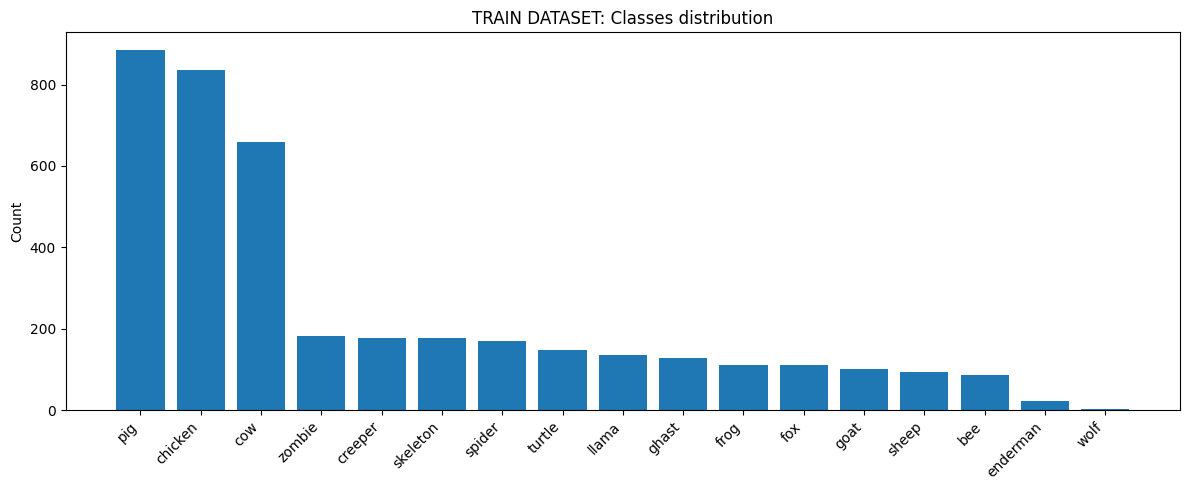

In [11]:
draw_distribution(train_annotation_path, "train")

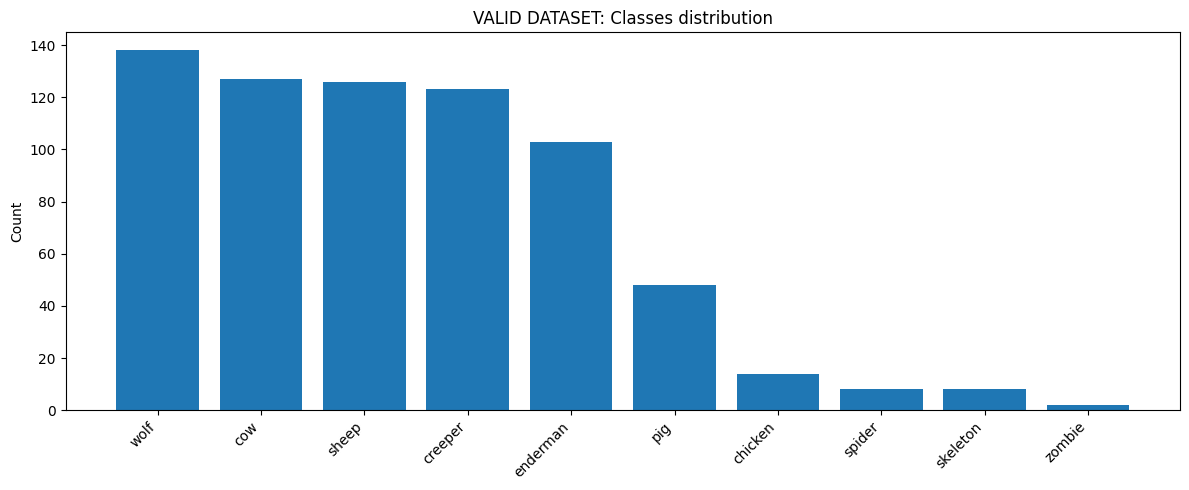

In [12]:
draw_distribution(valid_annotation_path, "valid")

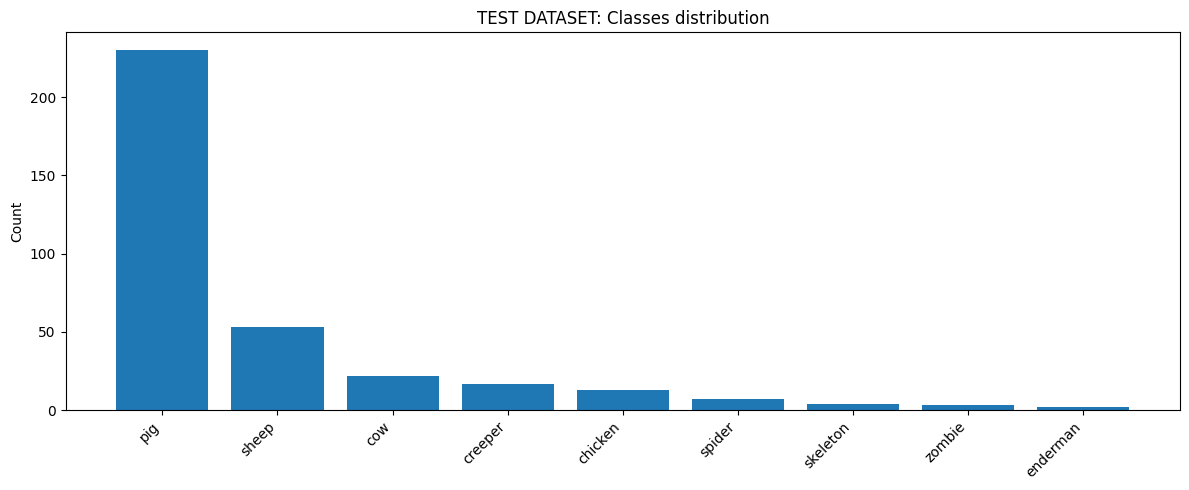

In [13]:
draw_distribution(test_annotation_path, "test")

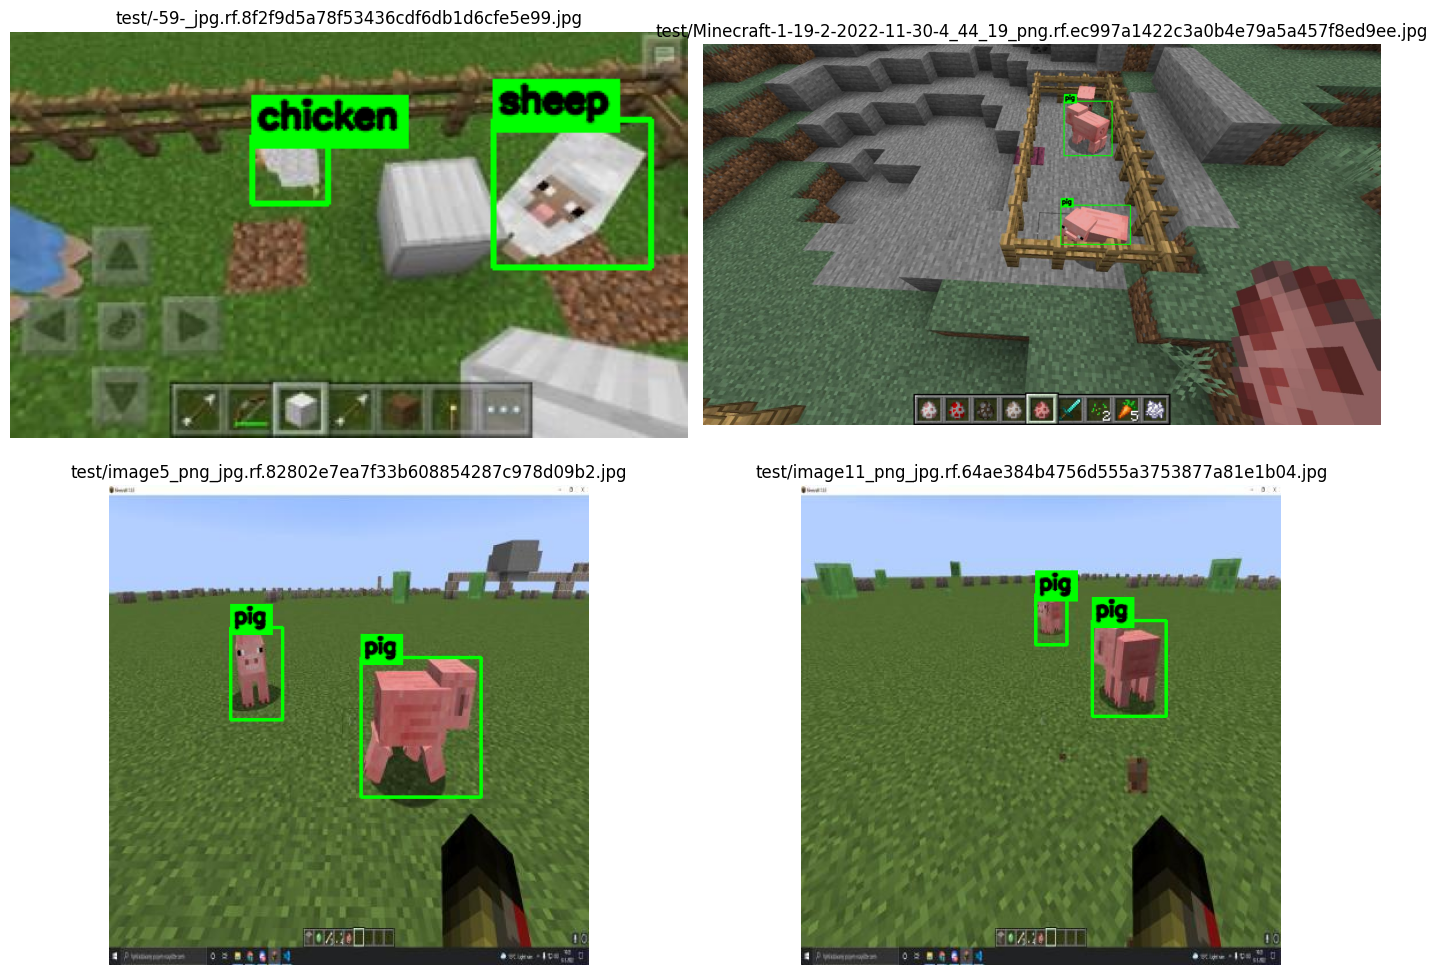

In [14]:
visualize_images_with_boxes(test_annotation_path, minecraft_test_dataset_path)

### Report

1. A discrepancy between the number of images and the number of labels was detected in the training dataset.
Images without labels were excluded from the dataset.

2. There is a class imbalance in the data.
To fill the dataset, we use augmentations and the "weighted classes" parameter in the models.

In [15]:
del check_dataset, voc_to_coco, draw_distribution, visualize_images_with_boxes

## Models

In [16]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


### Model's configuration and test run

In [17]:
artifacts_dir_path: Path = project_dir_path / Path("artifacts")
artifacts_inference_dir_path: Path = artifacts_dir_path / "inference"

print("ARTIFACTS DIR PATH:          ", artifacts_dir_path)
print("ARTIFACTS INFERENCE DIR PATH:", artifacts_inference_dir_path)

img_test_path = "datasets/minecraft/images/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg"

ARTIFACTS DIR PATH:           /home/ubuntu/mmdetection/mmdet/artifacts
ARTIFACTS INFERENCE DIR PATH: /home/ubuntu/mmdetection/mmdet/artifacts/inference


FCOS test run

In [18]:
config_fcos_path = "configs/fcos/fcos_minecraft.py"
weights = "checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth"

inferencer = DetInferencer(model=config_fcos_path, weights=weights, device=device)

out_test_start_fcos_dir: Path = artifacts_inference_dir_path / Path("fcos_val")
out_test_start_fcos_dir.mkdir(exist_ok=True, parents=True)
_ = inferencer(img_test_path, out_dir=out_test_start_fcos_dir, show=False)

Loads checkpoint by local backend from path: checkpoints/fcos_r50_caffe_fpn_gn-head_1x_coco-821213aa.pth
The model and loaded state dict do not match exactly

size mismatch for bbox_head.conv_cls.weight: copying a param with shape torch.Size([80, 256, 3, 3]) from checkpoint, the shape in current model is torch.Size([17, 256, 3, 3]).
size mismatch for bbox_head.conv_cls.bias: copying a param with shape torch.Size([80]) from checkpoint, the shape in current model is torch.Size([17]).
02/01 20:25:44 - mmengine - WARNING - Failed to search registry with scope "mmdet" in the "function" registry tree. As a workaround, the current "function" registry in "mmengine" is used to build instance. This may cause unexpected failure when running the built modules. Please check whether "mmdet" is a correct scope, or whether the registry is initialized.


Output()

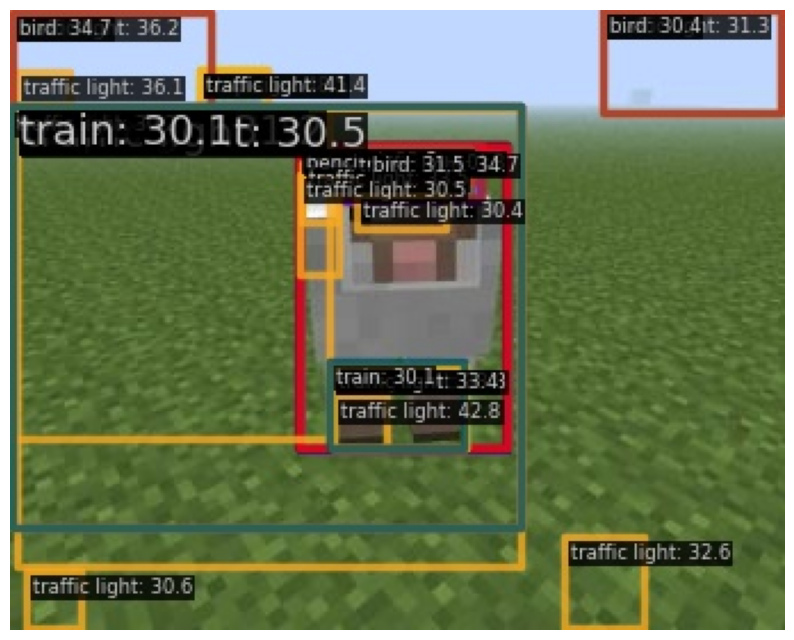

In [19]:
img_test_result_fcos_path: str = str(out_test_start_fcos_dir / Path("vis") / Path(img_test_path).name)
draw_pricture(img_test_result_fcos_path)

YOLO test run

In [20]:
model = YOLO("yolov8s.pt")

out_test_start_yolo_dir = artifacts_inference_dir_path / Path("yolo_val")
out_test_start_yolo_dir.mkdir(parents=True, exist_ok=True)

_ = model.predict(
    source=img_test_path,
    conf=0.25,
    imgsz=640,
    save=True,
    project=str(out_test_start_yolo_dir),
    name="",
    exist_ok=True
)


image 1/1 /home/ubuntu/mmdetection/mmdet/datasets/minecraft/images/test/-5-_jpg.rf.bc815ec81b67584c880eb373c6de746a.jpg: 512x640 (no detections), 55.5ms
Speed: 2.2ms preprocess, 55.5ms inference, 0.7ms postprocess per image at shape (1, 3, 512, 640)
Results saved to /home/ubuntu/mmdetection/mmdet/artifacts/inference/yolo_val/predict


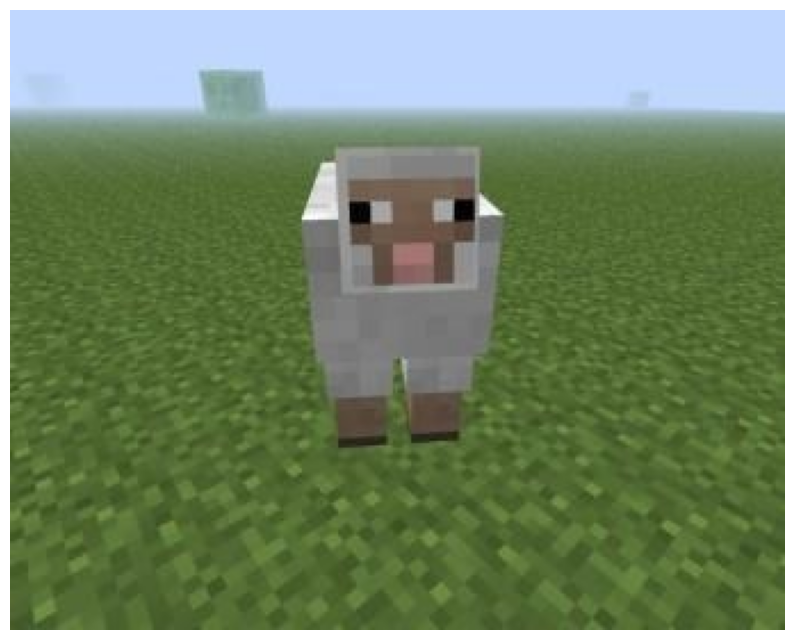

In [21]:
img_test_result_yolo_path: str = str(out_test_start_yolo_dir / Path("predict") / Path(img_test_path).name)
draw_pricture(img_test_result_yolo_path)

In [22]:
del draw_pricture

### Models train

In [23]:
artifacts_fcos_dir_path: Path = artifacts_dir_path / Path("fcos")
artifacts_fcos_dir_path.mkdir(exist_ok=True, parents=True)
artifacts_yolo_dir_path: Path = artifacts_dir_path / Path("yolo")
artifacts_yolo_dir_path.mkdir(exist_ok=True, parents=True)

print("YOLO'S ARTIFACTS DIR PATH:", artifacts_yolo_dir_path)
print("FCOS'S ARTIFACTS DIR PATH:", artifacts_fcos_dir_path)

YOLO'S ARTIFACTS DIR PATH: /home/ubuntu/mmdetection/mmdet/artifacts/yolo
FCOS'S ARTIFACTS DIR PATH: /home/ubuntu/mmdetection/mmdet/artifacts/fcos


Fcos train

In [24]:
# cmd_body = f"""
#             python3 ../tools/train.py \
#             {config_fcos_path} \
#             --work-dir {artifacts_fcos_dir_path}
#             """

# cmd = textwrap.dedent(cmd_body).strip()
# print("COMMAND FOR START TRAIN FCOS:", cmd)
# subprocess.run(cmd, shell=True, check=True)

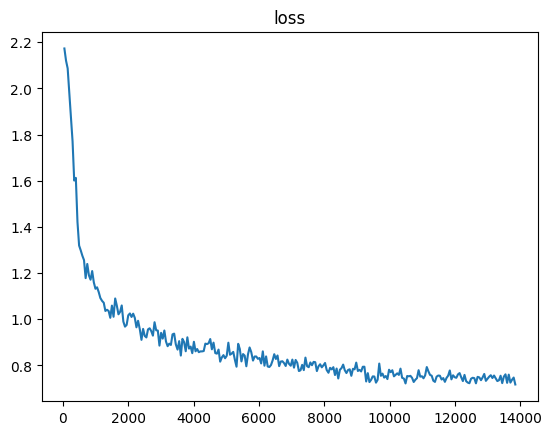

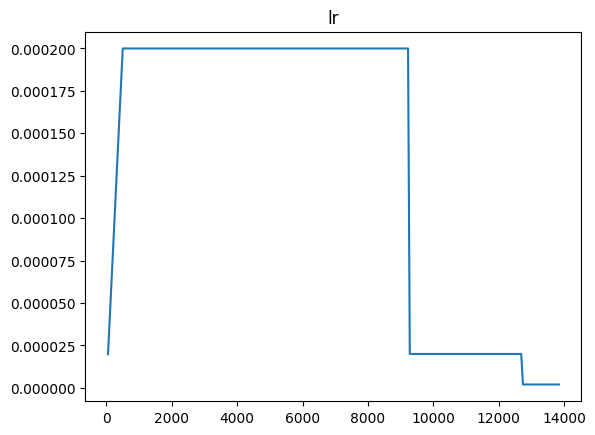

In [25]:
fcos_path_log = str("/home/ubuntu/mmdetection/mmdet/artifacts/fcos/20260201_115645/20260201_115645.log")
draw_fcos_metrics(fcos_path_log)

Yolo train

In [26]:
# model_yolo = YOLO("/home/ubuntu/mmdetection/mmdet/yolov8m.pt")

# res = model_yolo.train(
#     data=str(minecraft_dataset_dir_path / "data_voc.yaml"),
#     epochs=50,
#     imgsz=768,
#     batch=8,
#     device=0,
#     workers=4,

#     optimizer="auto",
#     cos_lr=True,

#     close_mosaic=20,
#     mosaic=0.7,
#     mixup=0.00,
#     copy_paste=0.0,

#     hsv_h=0.02,
#     hsv_s=0.8,
#     hsv_v=0.5,

#     patience=50,
#     project=str(artifacts_yolo_dir_path),
#     name="yolov8s_768_auto_aug",
#     exist_ok=True,
# )

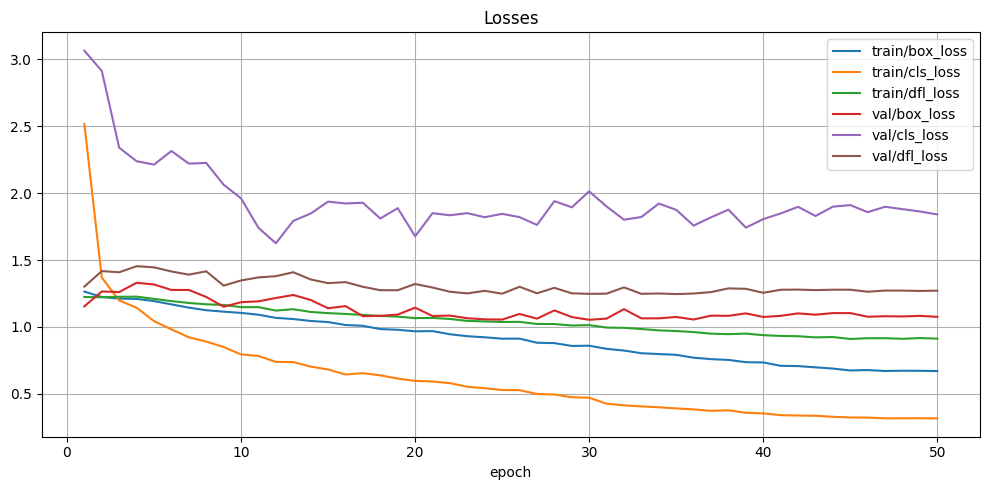

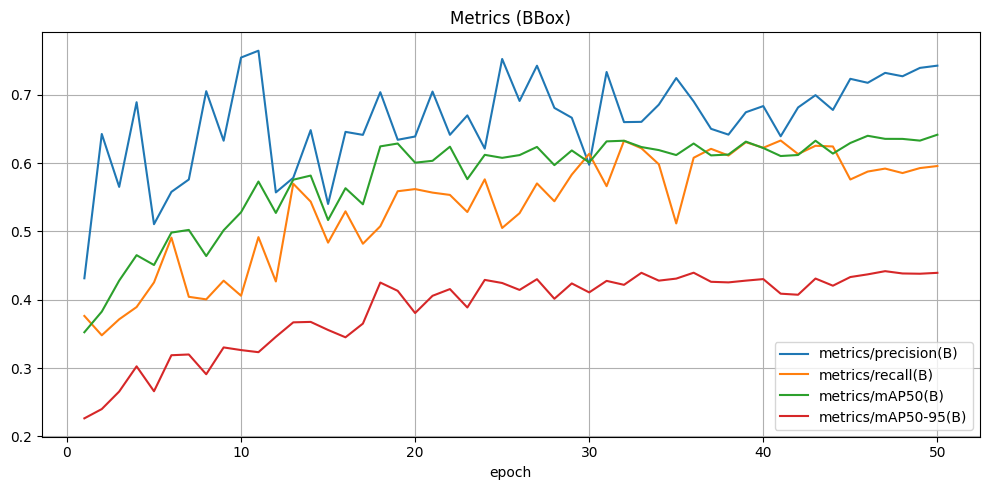

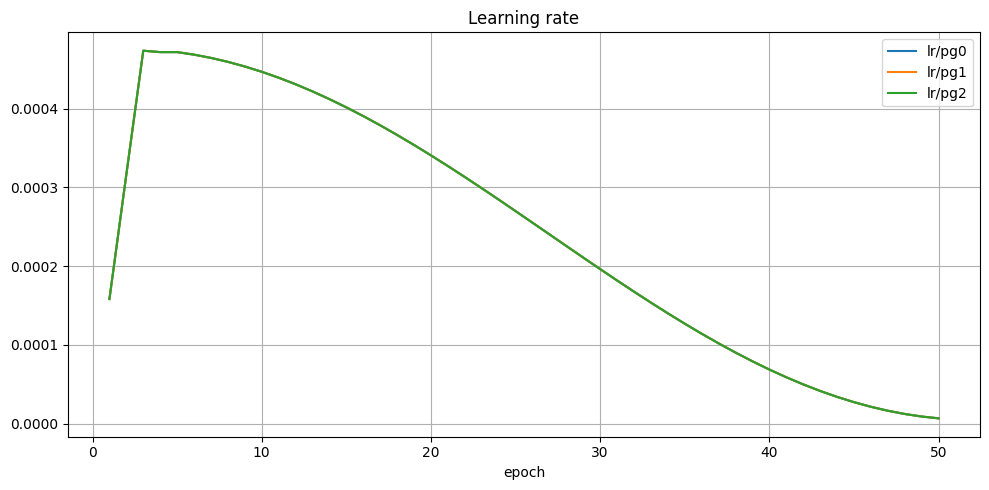

In [27]:
yolo_train_csv_metrics_path: str = str(artifacts_yolo_dir_path / Path("yolov8s_768_auto_aug/results.csv"))
draw_yolo_metrics(yolo_train_csv_metrics_path)

### Models test

In [28]:
yolo_best_pt_path: str = str(artifacts_yolo_dir_path / Path("yolov8s_768_auto_aug/weights/best.pt"))
out_test_images_yolo_dir: Path = artifacts_inference_dir_path / Path("yolov8m.pt")
inference_test_video_yolo: Path = artifacts_dir_path / Path("videos/yolo_inference.mp4")

fcos_last_checkpoint: Path = artifacts_fcos_dir_path / Path("epoch_12.pth")
out_test_images_fcos_dir: Path = artifacts_inference_dir_path / Path("fcos")
inferencet_test_video_fcos: Path = artifacts_dir_path / Path("videos/fcos_inference.mp4")

video_test_path: Path = minecraft_dataset_dir_path / Path("video.mp4")

YOLO test

In [29]:
model_yolo = YOLO(str(yolo_best_pt_path))

yolo_preds = model_yolo.predict(
    source=[str(path) for path in test_files_paths if path.suffix.lower()==".jpg"],
    imgsz=512,
    conf=0.25,
    save=True,
    save_txt=True,
    save_conf=True,
    project=str(out_test_images_yolo_dir.parent.resolve()),
    name=out_test_images_yolo_dir.name,
    exist_ok=True,
    verbose=False,
)

Results saved to /home/ubuntu/mmdetection/mmdet/artifacts/inference/yolov8m.pt
147 labels saved to /home/ubuntu/mmdetection/mmdet/artifacts/inference/yolov8m.pt/labels


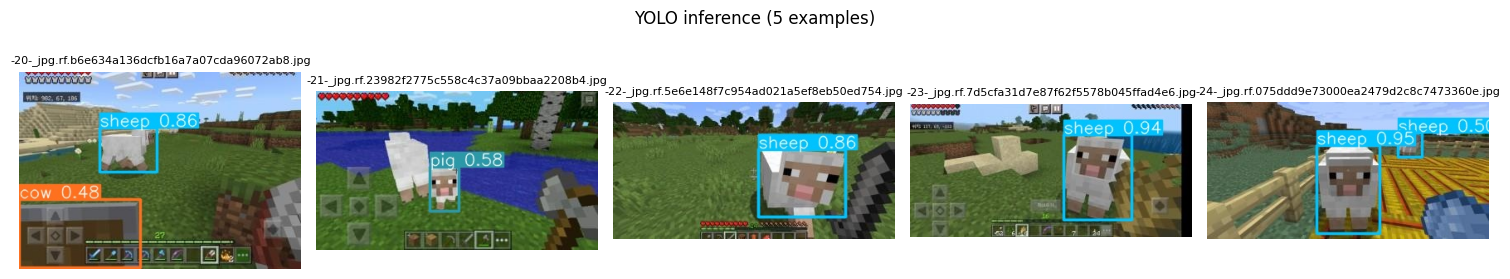

In [30]:
show_n_images(out_test_images_yolo_dir, n=5, title="YOLO inference (5 examples)")

In [31]:
# yolo_infer_fn = make_yolo_infer_fn(model_yolo)

# process_video_generic(
#     infer_on_frame_fn=yolo_infer_fn,
#     input_video_path=video_test_path,
#     output_video_path=inference_test_video_yolo,
#     confidence_threshold=0.25,
#     imgsz=512,
# )

FCOS test

In [32]:
fcos_infer = DetInferencer(
    model=str(config_fcos_path),
    weights=str(fcos_last_checkpoint),
    device="cuda:0",
)


fcos_preds = fcos_infer(
    inputs=[str(path) for path in test_files_paths if path.suffix.lower()==".jpg"],
    out_dir=str(out_test_images_fcos_dir),
    show=False,
    print_result=False,
    no_save_pred=False,
    return_datasamples=True,
)

Loads checkpoint by local backend from path: /home/ubuntu/mmdetection/mmdet/artifacts/fcos/epoch_12.pth


Output()

/home/ubuntu/.local/lib/python3.10/site-packages/mmdet/apis/det_inferencer.py:561: UserWarning: Currently does not 
support saving datasample when return_datasamples is set to True. Prediction results are not saved!
  warnings.warn('Currently does not support saving datasample '

/home/ubuntu/.local/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:760: UserWarning: Warning: 
The bbox is out of bounds, the drawn bbox may not be in the image
  warnings.warn(

/home/ubuntu/.local/lib/python3.10/site-packages/mmengine/visualization/visualizer.py:831: UserWarning: Warning: 
The polygon is out of bounds, the drawn polygon may not be in the image
  warnings.warn(

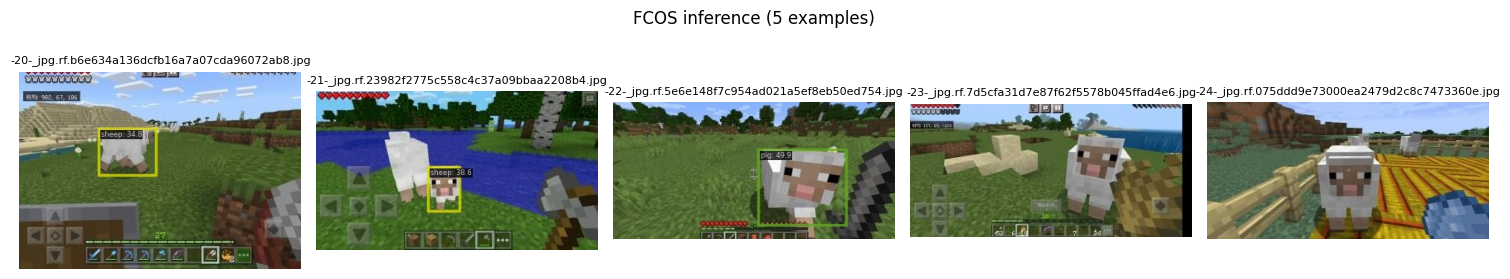

In [33]:
show_n_images(str(out_test_images_fcos_dir / Path("vis")), n=5, title="FCOS inference (5 examples)")

In [34]:
# fcos_infer_fn = make_fcos_infer_fn(
#     config_path=config_fcos_path,
#     checkpoint_path=fcos_last_checkpoint,
#     device="cuda:0",
#     class_names=CLASSES,
# )

# process_video_generic(
#     infer_on_frame_fn=fcos_infer_fn,
#     input_video_path=video_test_path,
#     output_video_path=inferencet_test_video_fcos,
#     confidence_threshold=0.25,
#     imgsz=768,
# )

## Compare metrics

In [35]:
preds_fcos = fcos_outputs_to_preds(fcos_preds, conf_thr=0.25)
test_imgs = [str(p) for p in test_files_paths if p.suffix.lower()==".jpg"]

t0 = time.perf_counter()
_ = fcos_infer(
    inputs=test_imgs,
    show=False,
    print_result=False,
    no_save_pred=True,
    return_datasamples=False,
)
t1 = time.perf_counter()

fps_fcos = len(test_imgs) / (t1 - t0)
fps_fcos

preds_yolo, shapes = yolo_results_to_preds(yolo_preds, conf_thr=0.25)
fps_yolo = fps_from_ultralytics_speed(yolo_preds)
num_classes = len(yolo_preds[0].names)

metrics_yolo = evaluate_detection_map_pr(preds_yolo, shapes, num_classes=num_classes, conf_thr=0.25)
metrics_yolo["FPS"] = float(fps_yolo) if fps_yolo is not None else None

metrics_fcos = evaluate_detection_map_pr(preds_fcos, shapes, num_classes=num_classes, conf_thr=0.25)
metrics_fcos["FPS"] = None

df_metrics_comparison = pd.DataFrame(
    [
        {"Model": "FCOS", **metrics_fcos},
        {"Model": "YOLO", **metrics_yolo},
    ],
    columns=["Model","mAP","mAP_50","Precision","Recall","F1-score","FPS"]
)

df_metrics_comparison.loc[df_metrics_comparison["Model"]=="FCOS", "FPS"] = float(fps_fcos)


out_csv: Path = Path(artifacts_dir_path / "metrics/metrics_comparison.csv")
out_csv.parent.mkdir(parents=True, exist_ok=True)
df_metrics_comparison.to_csv(out_csv, index=False)

Output()

NameError: name 'evaluate_detection_map_pr' is not defined

In [ ]:
print(df_metrics_comparison)

### Report

According to the experimental results, YOLOv8 is the preferred model for this dataset.

It simultaneously surpasses FCOS in quality (mAP +0.167) and speed (≈+68.7 FPS).

To further improve FCOS, it is worth considering: increasing the input size/multiscale, balancing
classes, NMS/threshold settings, and inference optimization (FP16, TensorRT).